## Project Story & Decision Journey

1. Started with T-Learner — simple baseline
2. T-Learner struggled with 2/3 treatment, 1/3 control imbalance
3. Tried X-Learner — manually implemented since sklift doesn't have it
4. Added Class Transformation —  best performer of implemented 5
5. Added Neural Network — to test if complex patterns exist
6. Result: Class Transformation wins — random assignment 
   favors direct uplift classification

**Key Business Constraint:**
Hillstrom has 3 treatments — Men email, Women email, No email
We combined Men+Women into single treatment to focus on:
"Does email cause visit?" not "Which email is better?"

**Key Assumption — RCT:**
Hillstrom uses random assignment — no confounders exist.
In real world targeted campaigns:
- Recency, history could become confounders
- Groups would no longer be balanced
- Class Transformation would fail — needs balanced groups
- Would need propensity scoring or DR-Learner instead

**Future Work:**
Apply same models on observational dataset (e.g. LaLonde) 
where confounders exist — compare results

In [1]:
import pandas as pd
from sklift.datasets import fetch_hillstrom

print("Fetching the 64,000 user Hillstrom dataset using scikit-uplift...")

#  directly from the package tool
dataset = fetch_hillstrom()



Fetching the 64,000 user Hillstrom dataset using scikit-uplift...


c:\Users\GADDAM'S\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Causal DAG - Hillstrom Dataset

![DAG](dag2.png)

**Treatment:** Email Campaign
**Outcome:** Visit
**Covariates:** Recency, History, Channel, Newbie, Zipcode, Mens/Womens

**Key Insight:** No confounders because treatment was randomly assigned (RCT)

In [2]:
#  Creating a structured dataframe table
df = pd.DataFrame(dataset.data) # it's a bunch datatype
df['treatment'] = dataset.treatment #not a part of the data
df['target_visit'] = dataset.target


df.to_csv("hillstrom_marketing.csv", index=False) # saving the dataset

print("\nSuccess! Dataset recovered perfectly and saved as 'hillstrom_marketing.csv'")
df.head()


Success! Dataset recovered perfectly and saved as 'hillstrom_marketing.csv'


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,target_visit
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0


In [3]:

df_clean = pd.get_dummies(df, columns=['zip_code', 'channel', 'history_segment']) # one hot encoding

df_clean = df_clean.astype({col: 'int' for col in df_clean.select_dtypes('bool').columns}) # true or false to binary

print("Data successfully cleaned! Ready for machine learning models.")
df_clean.head()

Data successfully cleaned! Ready for machine learning models.


,recency,history,mens,womens,newbie,treatment,target_visit,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web,history_segment_1) $0 - $100,history_segment_2) $100 - $200,history_segment_3) $200 - $350,history_segment_4) $350 - $500,history_segment_5) $500 - $750,"history_segment_6) $750 - $1,000","history_segment_7) $1,000 +"
0,10,142.44,1,0,0,Womens E-Mail,0,0,1,0,0,1,0,0,1,0,0,0,0,0
1,6,329.08,1,1,1,No E-Mail,0,1,0,0,0,0,1,0,0,1,0,0,0,0
2,7,180.65,0,1,1,Womens E-Mail,0,0,1,0,0,0,1,0,1,0,0,0,0,0
3,9,675.83,1,0,1,Mens E-Mail,0,1,0,0,0,0,1,0,0,0,0,1,0,0
4,2,45.34,1,0,0,Womens E-Mail,0,0,0,1,0,0,1,1,0,0,0,0,0,0


In [4]:
from sklearn.model_selection import train_test_split

print("Original categories in treatment column:", df['treatment'].unique())

# 1.Treatment 
W_binary = df['treatment'].apply(lambda x: 0 if str(x).strip() == 'No E-Mail' else 1)#If it says 'No E-Mail', it is 0. Otherwise, it is 1.

print("\nVerify the corrected binary distribution:")
print(W_binary.value_counts())
#2. Target
y = df_clean['target_visit']

#3. features
X = df_clean.drop(columns=['target_visit', 'treatment'], errors='ignore')

# 4. Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test, W_train, W_test = train_test_split(
    X, y, W_binary, test_size=0.20, random_state=59
)

print("\n--- Data Split Complete ---")
print(f"Training Set Profiles: {X_train.shape[0]}")
print(f"Testing Set Profiles:  {X_test.shape[0]}")

Original categories in treatment column: <StringArray>
['Womens E-Mail', 'No E-Mail', 'Mens E-Mail']
Length: 3, dtype: str

Verify the corrected binary distribution:
treatment
1    42694
0    21306
Name: count, dtype: int64

--- Data Split Complete ---
Training Set Profiles: 51200
Testing Set Profiles:  12800


## Exploring TwoModels (T-Learner)

Used `help(TwoModels)` to understand the key parameters:

- `estimator_trmnt`: model trained on **treatment** group data
- `estimator_ctrl`: model trained on **control** group data  
- `method='vanilla'`: two completely independent models, no dependency between them

In [5]:
from sklift.models import TwoModels
from sklearn.ensemble import RandomForestClassifier

print("Training the T-Learner models...")

# Initialize two identical Random Forests each for treatment and control groups
model_treatment = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=59)
model_control = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=59)

# 
t_learner = TwoModels(
    estimator_trmnt=model_treatment, 
    estimator_ctrl=model_control, 
    method='vanilla'
)

# Fit using our corrected binary indicators
t_learner.fit(X=X_train, y=y_train, treatment=W_train)

# Generate Causal Uplift Scores
uplift_scores = t_learner.predict(X_test)

# Organize everything into an evaluation summary table
results_df = X_test.copy()
results_df['Actual_Treatment'] = W_test
results_df['Actual_Visit'] = y_test
results_df['Uplift_Score'] = uplift_scores

print("\n--- Model Evaluation Complete! ---")
results_df[['recency', 'history', 'Actual_Treatment', 'Actual_Visit', 'Uplift_Score']].head()

Training the T-Learner models...

--- Model Evaluation Complete! ---


,recency,history,Actual_Treatment,Actual_Visit,Uplift_Score
47226,4,210.46,1,0,0.047080
8419,4,255.11,0,0,0.053819
3977,7,90.19,1,0,0.064439
20877,9,445.23,1,0,0.088243
41352,2,29.99,1,0,0.056843


In [ ]:
import matplotlib.pyplot as plt

# Helper function to generate Qini curves from our results data frame
def get_qini_curve(score_column):
    df_sorted = results_df.sort_values(by=score_column, ascending=False).reset_index(drop=True)
    num_cust = np.arange(1, len(df_sorted) + 1)
    cum_trmnt = df_sorted['Actual_Treatment'].cumsum()
    cum_ctrl = num_cust - cum_trmnt
    cum_y_trmnt = (df_sorted['Actual_Visit'] * df_sorted['Actual_Treatment']).cumsum()
    cum_y_ctrl = (df_sorted['Actual_Visit'] * (1 - df_sorted['Actual_Treatment'])).cumsum()
    
    with np.errstate(invalid='ignore', divide='ignore'):
        qini = cum_y_trmnt - cum_y_ctrl * (cum_trmnt / cum_ctrl)
        qini = np.where(cum_ctrl == 0, cum_y_trmnt, qini)
    return num_cust, qini

Calculating cumulative causal curves directly from data...


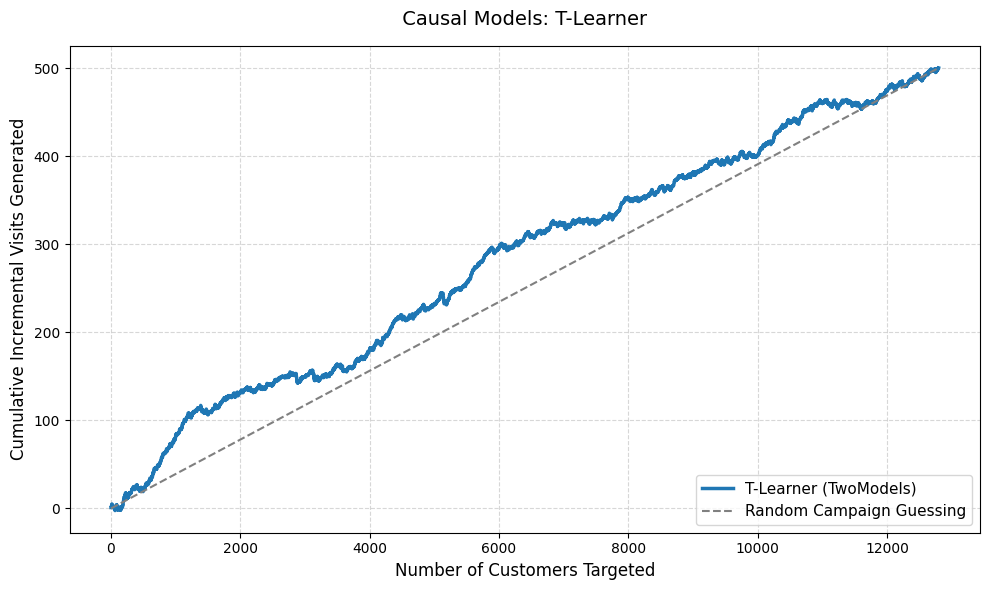

Total pure incremental traffic generated by full rollout: 500 extra visits.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("Calculating cumulative causal curves directly from data...")


num_customers, qini_curve = get_qini_curve('Uplift_Score')

# 4. Generate a clean random baseline trajectory
# 6. Plot BOTH models side-by-side against the baseline!
plt.figure(figsize=(10, 6))
plt.plot(num_customers, qini_curve, label='T-Learner (TwoModels)', color='#1f77b4', linewidth=2.5)

plt.plot(num_customers, random_baseline, label='Random Campaign Guessing', color='gray', linestyle='--', linewidth=1.5)

plt.title(' Causal Model: T-Learner ', fontsize=14, pad=15)
plt.xlabel('Number of Customers Targeted', fontsize=12)
plt.ylabel('Cumulative Incremental Visits Generated', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Total pure incremental traffic generated by full rollout: {int(qini_curve[-1])} extra visits.")

## Exploring SoloModel (S-Learner)

Used `help(SoloModel)` to understand the key parameters:

- `estimator`: Single ML model (RandomForestClassifier) 
  that learns from ALL data — treatment and control together
- `treatment`: Treatment indicator column passed during fit
- `method='dummy'`: Treatment added as extra feature — 
  model predicts twice (treatment=1 and treatment=0) 
  then subtracts to get uplift

**Why S-Learner:** Simple, fast, one model

**Limitation:** Treatment dilution — model may ignore 
treatment signal if other features are stronger predictors

Training the S-Learner (SoloModel) Brain...
S-Learner training complete! Calculating the new cumulative curve...


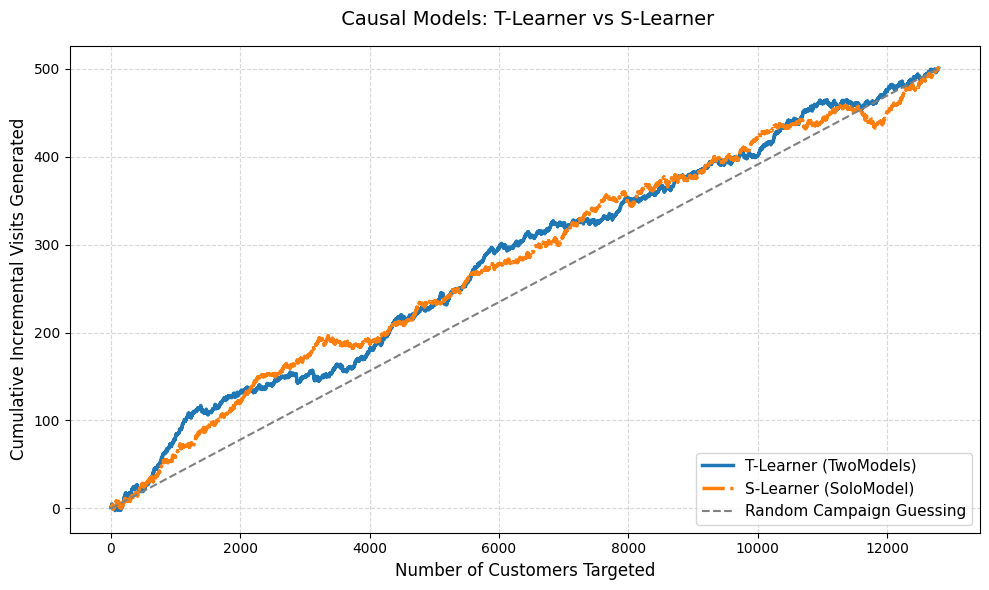

In [20]:
from sklift.models import SoloModel
from sklearn.ensemble import RandomForestClassifier

print("Training the S-Learner (SoloModel) Brain...")

# 1. The S-Learner only needs ONE base model because it looks at everything together
base_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=59)
s_learner = SoloModel(estimator=base_model)

# 2. Training the single model using all training data
s_learner.fit(X=X_train, y=y_train, treatment=W_train)

# 3. Predicting the uplift scores for the test users using the S-Learner
s_uplift_scores = s_learner.predict(X_test)

# 4. Add the new scores to our results dataframe
results_df['Uplift_Score_S'] = s_uplift_scores

print("S-Learner training complete! Calculating the new cumulative curve...")

# 5. Sort data by the S-Learner scores to calculate its custom Qini curve
num_customers, qini_curve_s = get_qini_curve('Uplift_Score_S')

# 6. Plot BOTH models side-by-side against the baseline!
plt.figure(figsize=(10, 6))
plt.plot(num_customers, qini_curve, label='T-Learner (TwoModels)', color='#1f77b4', linewidth=2.5)
plt.plot(num_customers, qini_curve_s, label='S-Learner (SoloModel)', color='#ff7f0e', linewidth=2.5, linestyle='-.')
plt.plot(num_customers, random_baseline, label='Random Campaign Guessing', color='gray', linestyle='--', linewidth=1.5)

plt.title(' Causal Models: T-Learner vs S-Learner', fontsize=14, pad=15)
plt.xlabel('Number of Customers Targeted', fontsize=12)
plt.ylabel('Cumulative Incremental Visits Generated', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## X-Learner (Custom Implementation)

X-Learner is not available in sklift — implemented manually using sklearn.

**4 models are built:**

- `m_trmnt`: Treatment outcome model (trained on treatment group)
- `m_ctrl`: Control outcome model (trained on control group)
- `mx_trmnt`: Effect model trained on treatment group imputed effects
- `mx_ctrl`: Effect model trained on control group imputed effects

**Why 4 models:**
- Stage 1: T-Learner style separate training
- Stage 2: Cross predictions to estimate counterfactual effects
- Final: Weighted average based on group size (2/3 treatment, 1/3 control)

**Why X-Learner:** Best for imbalanced groups like Hillstrom (2/3 treatment, 1/3 control)

**Limitation:** Complex to implement — requires careful weighting

Running Custom Multi-Stage X-Learner Imputation...
X-Learner complete! Generating final 3-way comparison plot...


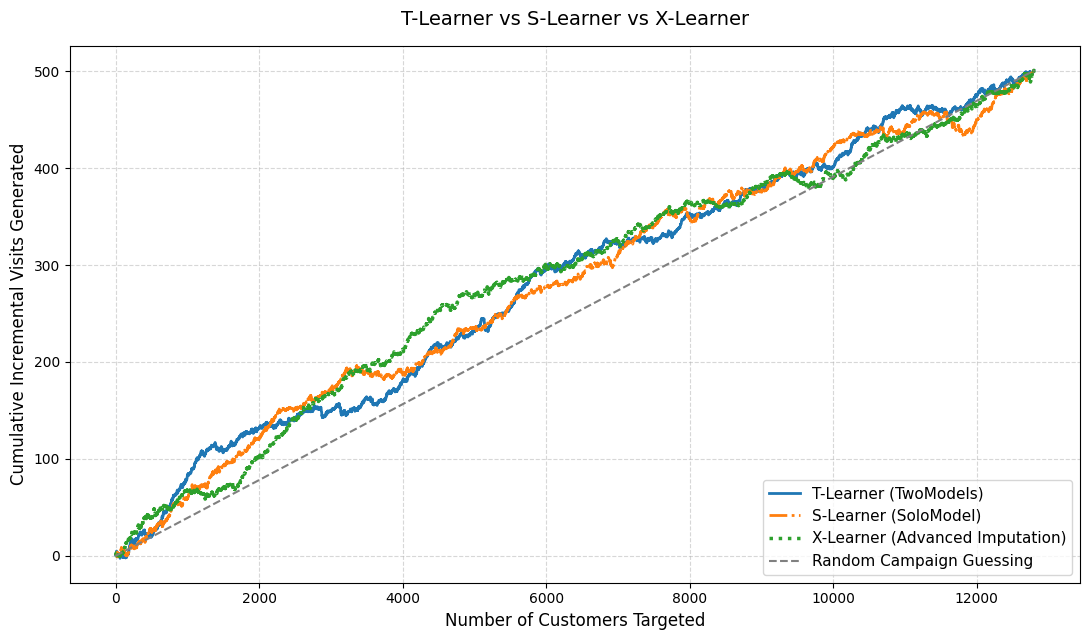

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("Running Custom Multi-Stage X-Learner Imputation...")

#  Train separate base models (Like a T-Learner)
m_trmnt = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=59).fit(X_train[W_train == 1], y_train[W_train == 1])
m_ctrl = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=59).fit(X_train[W_train == 0], y_train[W_train == 0])

#  Calculate Imputed Counterfactual Effects

d_trmnt = y_train[W_train == 1] - m_ctrl.predict_proba(X_train[W_train == 1])[:, 1]

d_ctrl = m_trmnt.predict_proba(X_train[W_train == 0])[:, 1] - y_train[W_train == 0]

# Step 3: Train two effect models to predict those hidden counterfactual differences

from sklearn.ensemble import RandomForestRegressor
mx_trmnt = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_train[W_train == 1], d_trmnt)
mx_ctrl = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42).fit(X_train[W_train == 0], d_ctrl)

# Step 4: Combine the scores for our test set based on propensity weights
propensity = np.mean(W_train) # Weighting factor based on group size
x_uplift_scores = propensity * mx_ctrl.predict(X_test) + (1 - propensity) * mx_trmnt.predict(X_test)
results_df['Uplift_Score_X'] = x_uplift_scores

print("X-Learner complete! Generating final 3-way comparison plot...")

# Step 5: Build X-Learner Curve Data
num_customers, qini_curve_x = get_qini_curve('Uplift_Score_X')

# Step 6: Render the Graph
plt.figure(figsize=(11, 6.5))
plt.plot(num_customers, qini_curve, label='T-Learner (TwoModels)', color='#1f77b4', linewidth=2)
plt.plot(num_customers, qini_curve_s, label='S-Learner (SoloModel)', color='#ff7f0e', linewidth=2, linestyle='-.')
plt.plot(num_customers, qini_curve_x, label='X-Learner (Advanced Imputation)', color='#2ca02c', linewidth=2.5, linestyle=':')
plt.plot(num_customers, random_baseline, label='Random Campaign Guessing', color='gray', linestyle='--', linewidth=1.5)

plt.title('T-Learner vs S-Learner vs X-Learner', fontsize=14, pad=15)
plt.xlabel('Number of Customers Targeted', fontsize=12)
plt.ylabel('Cumulative Incremental Visits Generated', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Class Transformation (Direct Uplift Classification)

Uses `ClassTransformation` from sklift.

**Key Idea:** Reframes uplift as a single classification problem.

**How it works:**
- Creates new target Z combining treatment and outcome:
  - Treated AND visited = 1 ✅
  - Control AND NOT visited = 1 ✅
  - Treated AND NOT visited = 0 ❌
  - Control AND visited = 0 ❌
- Trains ONE model to predict P(Z=1)
- P(Z=1) directly = uplift score

**Why Class Transformation:** No subtraction needed — 
uplift predicted in one shot

**Limitation:** Assumes balanced treatment and control groups — 
slightly biased for Hillstrom (2/3 treatment, 1/3 control)

Training the Direct Class Transformation Model...
Class Transformation trainig complete


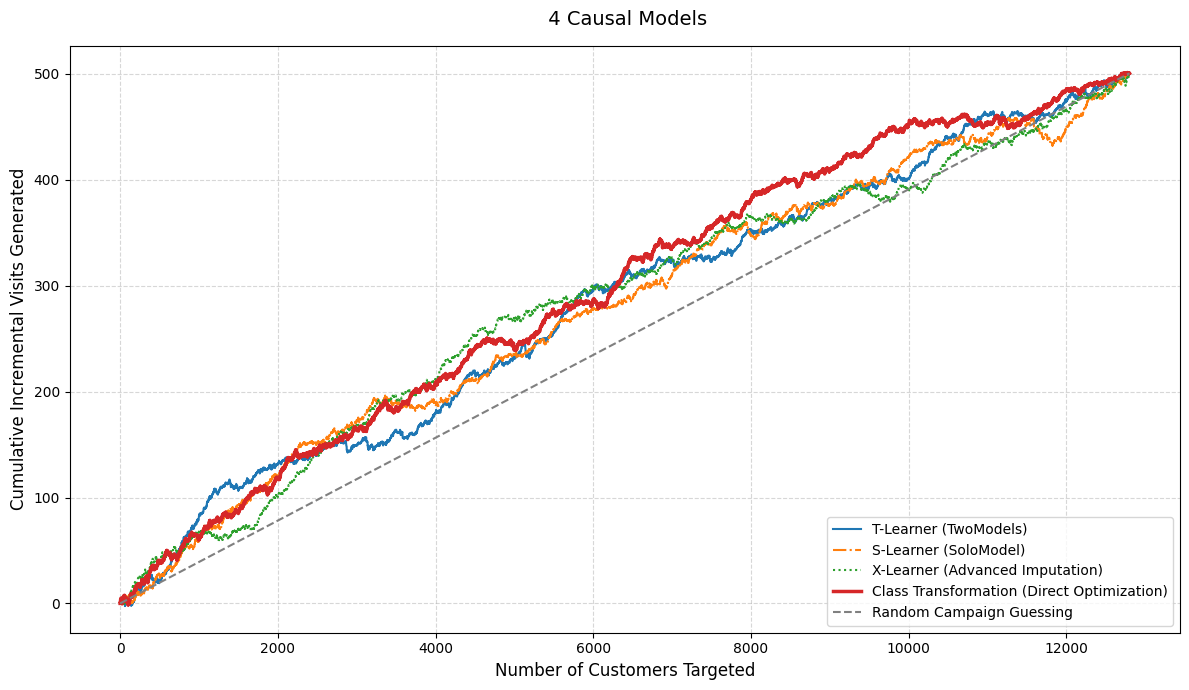

In [ ]:
from sklift.models import ClassTransformation
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

print("Training the  Class Transformation Model...")

# 1. Initialize the base classifier
base_ct_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. Wrap it in the ClassTransformation framework
ct_learner = ClassTransformation(estimator=base_ct_model)

# 3. Fit the model using our training sets
ct_learner.fit(X=X_train, y=y_train, treatment=W_train)

# 4. Predict the scores for the test set
ct_uplift_scores = ct_learner.predict(X_test)


results_df['Uplift_Score_CT'] = ct_uplift_scores

print("Class Transformation trainig complete")

# 5. Calculate the Qini curve for Class Transformation
num_customers, qini_curve_ct = get_qini_curve('Uplift_Score_CT')

# 6. Plot all 4 models together!
plt.figure(figsize=(12, 7))
plt.plot(num_customers, qini_curve, label='T-Learner (TwoModels)', color='#1f77b4', linewidth=1.5)
plt.plot(num_customers, qini_curve_s, label='S-Learner (SoloModel)', color='#ff7f0e', linewidth=1.5, linestyle='-.')
plt.plot(num_customers, qini_curve_x, label='X-Learner (Advanced Imputation)', color='#2ca02c', linewidth=1.5, linestyle=':')
plt.plot(num_customers, qini_curve_ct, label='Class Transformation (Direct Optimization)', color='#d62728', linewidth=2.5)
plt.plot(num_customers, random_baseline, label='Random Campaign Guessing', color='gray', linestyle='--', linewidth=1.5)

plt.title(' 4 Causal Models', fontsize=14, pad=15)
plt.xlabel('Number of Customers Targeted', fontsize=12)
plt.ylabel('Cumulative Incremental Visits Generated', fontsize=12)
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Neural Network T-Learner (MLPRegressor)

Two separate Neural Networks — same logic as T-Learner but with MLP.

**Architecture:**
- `hidden_layer_sizes=(64, 32)`: 2 hidden layers
- Layer 1: 64 neurons
- Layer 2: 32 neurons
- `max_iter=200`: Maximum training iterations

**How it works:**
- `nn_trmnt`: MLP trained on treatment group only
- `nn_ctrl`: MLP trained on control group only
- Uplift = nn_trmnt.predict(X_test) - nn_ctrl.predict(X_test)

**Why Neural Network:** Captures complex non-linear 
feature interactions that tree models may miss

**Limitation:** With only 8 features and 64k rows, 
Random Forest likely performs similarly — Neural Networks 
shine on larger, more complex datasets

Running Multi-Layer Perceptron Neural Uplift Engine...
Neural Network Causal Inference complete!


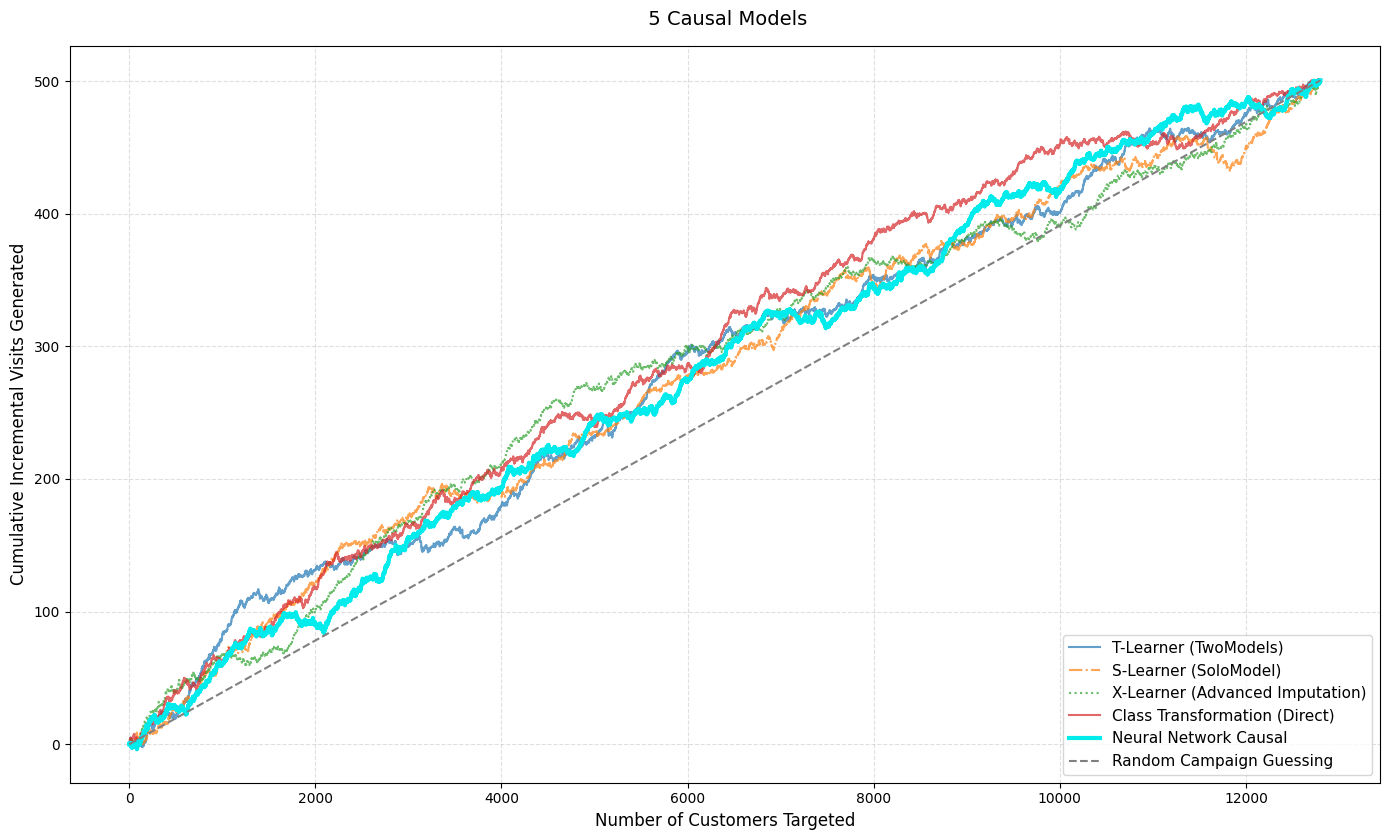

In [31]:
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import numpy as np

print("Running Multi-Layer Perceptron Neural Uplift Engine...")

nn_trmnt = MLPRegressor(hidden_layer_sizes=(64, 32), random_state=42, max_iter=200)
nn_ctrl = MLPRegressor(hidden_layer_sizes=(64, 32), random_state=42, max_iter=200)

nn_trmnt.fit(X_train[W_train == 1], y_train[W_train == 1])
nn_ctrl.fit(X_train[W_train == 0], y_train[W_train == 0])

results_df['Uplift_Score_NN'] = nn_trmnt.predict(X_test) - nn_ctrl.predict(X_test)

print("Neural Network Causal Inference complete!")


# Generating curve
num_cust, qini_nn = get_qini_curve('Uplift_Score_NN')

# 
plt.figure(figsize=(14, 8.5))
plt.plot(num_cust, qini_curve, label='T-Learner (TwoModels)', color='#1f77b4', linewidth=1.5, alpha=0.7)
plt.plot(num_cust, qini_curve_s, label='S-Learner (SoloModel)', color='#ff7f0e', linewidth=1.5, linestyle='-.', alpha=0.7)
plt.plot(num_cust, qini_curve_x, label='X-Learner (Advanced Imputation)', color='#2ca02c', linewidth=1.5, linestyle=':', alpha=0.7)
plt.plot(num_cust, qini_curve_ct, label='Class Transformation (Direct)', color='#d62728', linewidth=1.5, alpha=0.7)
plt.plot(num_cust, qini_nn, label='Neural Network Causal', color='#00ecec', linewidth=3)

# Baseline
plt.plot(num_cust, random_baseline, label='Random Campaign Guessing', color='gray', linestyle='--', linewidth=1.5)

plt.title(' 5 Causal Models', fontsize=14, pad=15)
plt.xlabel('Number of Customers Targeted', fontsize=12)
plt.ylabel('Cumulative Incremental Visits Generated', fontsize=12)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Model Comparison - AUUC Scores

Higher AUUC = better uplift ranking = more incremental visits

Note: Low absolute values are normal for uplift models —
email campaigns have inherently small incremental effects.
What matters is relative ranking between models.

In [28]:
from sklift.metrics import uplift_auc_score
auuc_t = uplift_auc_score(y_test, results_df['Uplift_Score'], W_test)
auuc_s = uplift_auc_score(y_test, results_df['Uplift_Score_S'], W_test)
auuc_x = uplift_auc_score(y_test, results_df['Uplift_Score_X'], W_test)
auuc_ct = uplift_auc_score(y_test, results_df['Uplift_Score_CT'], W_test)
auuc_mlp= uplift_auc_score(y_test, results_df['Uplift_Score_NN'], W_test)

print("="*40)
print("Model         | AUUC Score")
print("="*40)
print(f"T-Learner     | {auuc_t:.4f}")
print(f"S-Learner     | {auuc_s:.4f}")
print(f"X-Learner     | {auuc_x:.4f}")
print(f"Class Trans   | {auuc_ct:.4f}")
print(f"Neural Network| {auuc_mlp:.4f}")
print("="*40)

Model         | AUUC Score
T-Learner     | 0.0161
S-Learner     | 0.0165
X-Learner     | 0.0174
Class Trans   | 0.0243
Neural Network| 0.0169


c:\Users\GADDAM'S\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\GADDAM'S\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
c:\Users\GADDAM'S\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `n

## Policy Analysis - Quintile Lift Table
Best Model (Class Transformation)
Validates model by checking if high uplift customers 
actually convert more when treated.

**How to read:**
- Tier 1 = highest predicted uplift customers
- Real_Causal_Lift = Treated visit rate - Control visit rate
- Tier 1 should have highest lift = model is working!

**Business Use:**
- Budget constrained → target Tier 1 only
- More budget → expand to Tier 2, 3
- NEVER target negative lift tiers → Sleeping Dogs!

In [33]:
import numpy as np
print("=== Policy Value: Quintile Lift Analysis ===")
# 1.  5 equal-sized tiers (Quintiles) based on their Uplift Scores
results_df['Uplift_Tier'] = pd.qcut(results_df['Uplift_Score_CT'], q=5, 
                                    labels=['Tier 5 (Lowest)', 'Tier 4', 'Tier 3', 'Tier 2', 'Tier 1 (Highest)'])

#2 Calculating the actual visit rates for treated and control groups within each tier 
summary = results_df.groupby('Uplift_Tier', observed=False).apply(lambda g: pd.Series({
    'Treated_Visit_Rate': np.mean(g[g['Actual_Treatment'] == 1]['Actual_Visit']) * 100,
    'Control_Visit_Rate': np.mean(g[g['Actual_Treatment'] == 0]['Actual_Visit']) * 100
})).reset_index()

# 3. Calculating the uplift
summary['Real_Causal_Lift'] = summary['Treated_Visit_Rate'] - summary['Control_Visit_Rate']

print("--- Real-World Impact Across Customer Tiers ---")
summary[['Uplift_Tier', 'Treated_Visit_Rate', 'Control_Visit_Rate', 'Real_Causal_Lift']].sort_values('Uplift_Tier', ascending=False)

=== Policy Value: Quintile Lift Analysis ===
--- Real-World Impact Across Customer Tiers ---


,Uplift_Tier,Treated_Visit_Rate,Control_Visit_Rate,Real_Causal_Lift
4,Tier 1 (Highest),24.400234,15.746181,8.654053
3,Tier 2,18.467933,12.571429,5.896505
2,Tier 3,16.521739,9.832134,6.689605
1,Tier 4,13.497990,8.038977,5.459013
0,Tier 5 (Lowest),9.851632,7.200000,2.651632


## Policy Analysis - Quintile Lift Comparison

Comparing T-Learner vs Best Model (Class Transformation)

Does better AUUC translate to better tier separation?

In [34]:
import numpy as np
print("=== Policy Value: Quintile Lift Analysis ===")
# 1.  5 equal-sized tiers (Quintiles) based on their Uplift Scores
results_df['Uplift_Tier'] = pd.qcut(results_df['Uplift_Score'], q=5, 
                                    labels=['Tier 5 (Lowest)', 'Tier 4', 'Tier 3', 'Tier 2', 'Tier 1 (Highest)'])

#2 Calculating the actual visit rates for treated and control groups within each tier 
summary = results_df.groupby('Uplift_Tier', observed=False).apply(lambda g: pd.Series({
    'Treated_Visit_Rate': np.mean(g[g['Actual_Treatment'] == 1]['Actual_Visit']) * 100,
    'Control_Visit_Rate': np.mean(g[g['Actual_Treatment'] == 0]['Actual_Visit']) * 100
})).reset_index()

# 3. Calculating the uplift
summary['Real_Causal_Lift'] = summary['Treated_Visit_Rate'] - summary['Control_Visit_Rate']

print("--- Real-World Impact Across Customer Tiers ---")
summary[['Uplift_Tier', 'Treated_Visit_Rate', 'Control_Visit_Rate', 'Real_Causal_Lift']].sort_values('Uplift_Tier', ascending=False)

=== Policy Value: Quintile Lift Analysis ===
--- Real-World Impact Across Customer Tiers ---


,Uplift_Tier,Treated_Visit_Rate,Control_Visit_Rate,Real_Causal_Lift
4,Tier 1 (Highest),20.274914,11.916462,8.358452
3,Tier 2,16.004742,10.309278,5.695464
2,Tier 3,16.060081,11.097708,4.962373
1,Tier 4,14.210833,9.134045,5.076788
0,Tier 5 (Lowest),16.115454,11.036789,5.078665


## Limitations & Future Work

### Current Limitations:

1. **Hyperparameter Tuning**
   - Parameters selected manually based on bias-variance knowledge
   - Future: GridSearchCV for systematic optimization

2. **Cross Validation**
   - Single 80/20 split used
   - Future: 5-fold cross validation to report mean AUUC ± std

3. **Confidence Intervals**
   - Point estimates only — no uncertainty quantification
   - Future: Bootstrap confidence intervals for uplift scores

4. **Calibration**
   - Uplift scores not calibrated to actual probabilities
   - Future: Isotonic regression calibration

5. **Advanced Models Not Implemented**
   - **Dragonnet**: Requires shared representation with 
     separate outcome and propensity heads
   - **True Causal Forest**: Requires EconML — optimizes 
     tree splits on treatment heterogeneity directly
   - **DR-Learner (Doubly Robust)**: Combines outcome model 
     and propensity model for more robust estimates
   - **R-Learner**: Robinson decomposition for 
     observational data with confounders
   - Future: Implement these on observational dataset 
     with confounders (e.g. LaLonde dataset)

